# Step 4 Topic Modeling Results Analysis

In [1]:
import pandas as pd
import numpy as np
from bertopic import BERTopic

## 1 Read in Data, Model and Topics
### 1.1 Load Topic Model

In [2]:
topic_model = BERTopic.load("results/model_tfidf_model")

In [3]:
#get the topics frequencies
freq = topic_model.get_topic_info()
freq

,Topic,Count,Name,Representation,Representative_Docs
0,-1,923,-1_development_planning_building_process,"[development, planning, building, process, pol...",[decision maker facing unprecedented challenge...
1,0,453,0_gis_land_ca_growth,"[gis, land, ca, growth, automaton, cellular, p...",[zone cell parcel long regarded main unit anal...
2,1,151,1_accessibility_travel_cycling_commuting,"[accessibility, travel, cycling, commuting, bi...",[people value enjoy benefit use car brings qua...
3,2,81,2_design_style_designer_architectural,"[design, style, designer, architectural, archi...",[two experiment reported examine hypothesis co...
4,3,76,3_network_centrality_street_topology,"[network, centrality, street, topology, traffi...",[transportation research ha usually seen road ...
5,4,52,4_homeless_social_tourist_mobile,"[homeless, social, tourist, mobile, mobility, ...",[mobile internet emerges numerous instagram wo...
6,5,49,5_rectangular_adjacency_room_dissection,"[rectangular, adjacency, room, dissection, max...",[procedure described generates dissection rect...
7,6,49,6_facility_heuristic_problem_solution,"[facility, heuristic, problem, solution, cover...",[previous research effort demonstrate use loca...
8,7,48,7_energy_heat_temperature_canopy,"[energy, heat, temperature, canopy, carbon, tr...",[local climate change due urbanization epitomi...
9,8,47,8_segregation_ethnic_tract_residential,"[segregation, ethnic, tract, residential, gend...",[segregation highly nuanced concept researcher...


In [4]:
def __get_topic_allwords__(all_topics, t_model):
    '''
    get all ll word representing the topic
    :param all_topics: topics from freq df
    :param t_model: topic model
    :return: df with topic number, freq, all word representing the topic
    '''

    #create 3 empty list
    topic_list = []
    freq_list = []
    words_list = []

    for topic in all_topics:
        #topic_name = "Topic" + str(topic)
        #topic_list.append(topic_name)
        topic_list.append(topic)
        # print(topic_name)
        frq = t_model.get_topic_freq(topic)
        freq_list.append(frq)
        wordset = t_model.get_topic(topic)[:15]
        # print("====Get item from get_topic Results====")
        topic_word = []
        for item in wordset:
            # print()
            # topic_word += '' + str(item[0])
            topic_word.append(item[0])

        words_list.append(topic_word)
    # words_list.append(join(topic_word))
    topics_df = pd.DataFrame(list(zip(topic_list, freq_list, words_list)), columns=['Topic', 'Freq', 'Allwords'])
    return topics_df

In [5]:
# Get all word representing each topic from topic model
#from src.analysistools import __get_topic_allwords__
topic_allwords = __get_topic_allwords__(freq.Topic, topic_model)
print(topic_allwords.head())
#topic_allwords['Topic'] = topic_allwords['Topic'].astype(int)

   Topic  Freq                                           Allwords
0     -1   923  [development, planning, building, process, pol...
1      0   453  [gis, land, ca, growth, automaton, cellular, p...
2      1   151  [accessibility, travel, cycling, commuting, bi...
3      2    81  [design, style, designer, architectural, archi...
4      3    76  [network, centrality, street, topology, traffi...


### 1.2 Load Topic Overtime dataframe

In [6]:
topics_over_time = pd.read_csv("results/topics_over_time_tfidf_model.csv").iloc[:,1:]
topics_over_time[topics_over_time['Timestamp'] == 2023]

,Topic,Words,Frequency,Timestamp,Name
635,-1,"height, amenity, park, building, mobility",67,2023,-1_development_planning_building_process
636,0,"vitality, offshore, price, agglomeration, uscs",34,2023,0_gis_land_ca_growth
637,1,"cycling, transit, accessibility, parking, bike",27,2023,1_accessibility_travel_cycling_commuting
638,3,"cityseer, intercity, network, percolation, exp...",6,2023,3_network_centrality_street_topology
639,4,"lifestyle, motif, everyday, cdr, mobility",8,2023,4_homeless_social_tourist_mobile
640,7,"solar, occupant, canopy, tree, extreme",5,2023,7_energy_heat_temperature_canopy
641,8,"segregation, frontier, ethnic, linguistic, dep...",7,2023,8_segregation_ethnic_tract_residential
642,9,"ulvia, furniture, landmark, visibility, moveable",2,2023,9_visibility_isovist_museum_visible
643,10,"retail, ownership, plot, investor, hma",3,2023,10_shopping_retail_internet_store
644,12,"pedestrian, scbc, route, commercial, centrality",5,2023,12_pedestrian_walking_walkability_crossw...


In [324]:
#combine overtime and all topic 
merged_df = topics_over_time.merge(topic_allwords, how='left', on='Topic')
merged_df = merged_df[merged_df['Topic'] != -1]
merged_df.head()

,Topic,Words,Frequency,Timestamp,Name,Freq,Allwords
1,2,"wright, froebel, sullivan, kind, office",2,1974,2_design_style_designer_architectural,81,"[design, style, designer, architectural, archi..."
2,6,"teaching, timetabling, minimum, demand, utilis...",1,1974,6_facility_heuristic_problem_solution,49,"[facility, heuristic, problem, solution, cover..."
3,14,"regulation, bonus, sydney, floor, return",1,1974,14_architect_regulation_control_deregula...,29,"[architect, regulation, control, deregulation,..."
4,18,"heating, appliance, heat, costing, conservation",1,1974,18_nondomestic_stock_energy_building,23,"[nondomestic, stock, energy, building, floor, ..."
6,2,"krasil, nikov, aided, diploma, quoted",2,1975,2_design_style_designer_architectural,81,"[design, style, designer, architectural, archi..."


In [325]:
merged_df['normal_viz'] = merged_df['Frequency'] / merged_df['Freq'] 
merged_df.head()

,Topic,Words,Frequency,Timestamp,Name,Freq,Allwords,normal_viz
1,2,"wright, froebel, sullivan, kind, office",2,1974,2_design_style_designer_architectural,81,"[design, style, designer, architectural, archi...",0.024691
2,6,"teaching, timetabling, minimum, demand, utilis...",1,1974,6_facility_heuristic_problem_solution,49,"[facility, heuristic, problem, solution, cover...",0.020408
3,14,"regulation, bonus, sydney, floor, return",1,1974,14_architect_regulation_control_deregula...,29,"[architect, regulation, control, deregulation,...",0.034483
4,18,"heating, appliance, heat, costing, conservation",1,1974,18_nondomestic_stock_energy_building,23,"[nondomestic, stock, energy, building, floor, ...",0.043478
6,2,"krasil, nikov, aided, diploma, quoted",2,1975,2_design_style_designer_architectural,81,"[design, style, designer, architectural, archi...",0.024691


In [326]:
temp = merged_df.loc[:, ['Frequency', 'Timestamp']]
yearly_freq = temp.groupby('Timestamp').sum().reset_index().rename(columns={'Frequency':'T_Freq'})
merged_df = merged_df.merge(yearly_freq, how='left', on='Timestamp')
merged_df.head()

,Topic,Words,Frequency,Timestamp,Name,Freq,Allwords,normal_viz,T_Freq
0,2,"wright, froebel, sullivan, kind, office",2,1974,2_design_style_designer_architectural,81,"[design, style, designer, architectural, archi...",0.024691,5
1,6,"teaching, timetabling, minimum, demand, utilis...",1,1974,6_facility_heuristic_problem_solution,49,"[facility, heuristic, problem, solution, cover...",0.020408,5
2,14,"regulation, bonus, sydney, floor, return",1,1974,14_architect_regulation_control_deregula...,29,"[architect, regulation, control, deregulation,...",0.034483,5
3,18,"heating, appliance, heat, costing, conservation",1,1974,18_nondomestic_stock_energy_building,23,"[nondomestic, stock, energy, building, floor, ...",0.043478,5
4,2,"krasil, nikov, aided, diploma, quoted",2,1975,2_design_style_designer_architectural,81,"[design, style, designer, architectural, archi...",0.024691,6


In [327]:
merged_df['normal_viz_2'] = merged_df['Frequency'] / merged_df['T_Freq'] 
merged_df.head()

,Topic,Words,Frequency,Timestamp,Name,Freq,Allwords,normal_viz,T_Freq,normal_viz_2
0,2,"wright, froebel, sullivan, kind, office",2,1974,2_design_style_designer_architectural,81,"[design, style, designer, architectural, archi...",0.024691,5,0.400000
1,6,"teaching, timetabling, minimum, demand, utilis...",1,1974,6_facility_heuristic_problem_solution,49,"[facility, heuristic, problem, solution, cover...",0.020408,5,0.200000
2,14,"regulation, bonus, sydney, floor, return",1,1974,14_architect_regulation_control_deregula...,29,"[architect, regulation, control, deregulation,...",0.034483,5,0.200000
3,18,"heating, appliance, heat, costing, conservation",1,1974,18_nondomestic_stock_energy_building,23,"[nondomestic, stock, energy, building, floor, ...",0.043478,5,0.200000
4,2,"krasil, nikov, aided, diploma, quoted",2,1975,2_design_style_designer_architectural,81,"[design, style, designer, architectural, archi...",0.024691,6,0.333333


In [116]:
topic_model.visualize_topics_over_time(topics_over_time)

## 2 Split Data and Visualize
Split the data using Standard Deviation Classification with 3 groups
* less than (std_dev - mean_value)
* between (std_dev - mean_value) and (mean_value + std_dev)
* grater than (mean_value + std_dev)

In [256]:
def claasify_std(input_df):
    mean_value = np.mean(input_df.Freq[1:].unique())
    std_dev = np.std(input_df.Freq[1:].unique())
    print("mean", mean_value, "stddev", std_dev)
    group1 = input_df[input_df.Freq  <= 15]
    group2 = input_df[input_df.Freq  <= 15]
    group3 = input_df[(input_df.Freq <= 20) & (input_df.Freq > 15 )]
    group4 = input_df[(input_df.Freq >= (std_dev - mean_value)) & (input_df.Freq > 20)]
    group5 = input_df[input_df.Freq >=  (std_dev)]#.iloc[1:,:]
    
    return group1, group2, group3, group4

In [257]:
np.std(merged_df.Freq[1:].unique()) - np.mean(merged_df.Freq[1:].unique())

31.054111672175075

In [258]:
g1, g2, g3 , g4= claasify_std(merged_df)

mean 51.285714285714285 stddev 82.33982595788936


In [417]:
def __plot_area_groups(data, L):
    #print(data.head())
    import matplotlib.pyplot as plt
    if len(data.Topic.unique()) == 4:
        color_list = ['#4E62AB', '#87CFA4', '#FDB96A', '#D6404E']

    if len(data.Topic.unique()) == 5:
        color_list = ['#4E62AB', '#87CFA4', '#F5FBB1', '#FDB96A', '#D6404E']

    if len(data.Topic.unique()) == 6:
        color_list = ['#4E62AB', '#87CFA4', '#CBE99D', '#FEE89A', '#F57547', '#9E0142']

    if len(data.Topic.unique()) == 7:
        color_list = ['#4E62AB', '#469EB4', '#87CFA4', '#FEE89A', '#FDB96A', '#F57547', '#9E0142']

    if len(data.Topic.unique()) == 8:
        color_list = ['#4E62AB', '#469EB4', '#87CFA4', '#F5FBB1', '#FEE89A', '#FDB96A', '#F57547', '#9E0142']

    if len(data.Topic.unique()) == 9:
        color_list = ['#4E62AB', '#469EB4', '#87CFA4', '#F5FBB1', '#FEE89A', '#FDB96A', '#F57547', '#D6404E', '#9E0142']
    
    #pivot_df = data.pivot(index='Timestamp', columns='Topic', values='normal_viz_2').fillna(0)#.loc[:, [36,37,38]]
    pivot_df = data.pivot(index='Timestamp', columns='Topic', values='normal_viz').fillna(0)#.loc[:, [36,37,38]]
    #pivot_df = g1.pivot(index='Timestamp', columns='Topic', values='Frequency').fillna(0)#.loc[:, [36,37,38]]
    pivot_df = pivot_df.loc[(pivot_df != 0).any(axis=1)]

    # Plot stacked area chart
    #ax = pivot_df.plot(kind='area', stacked=True, figsize=(20, 10), linewidth=0, color=color_list)
    fig, ax = plt.subplots(figsize=(25, 10))
    #for column, color in zip(pivot_df.columns, color_list):
        #plt.fill_between(pivot_df.index, pivot_df[column], color=color, alpha=0.7)
    plt.stackplot(pivot_df.index, pivot_df.values.T, colors=color_list, labels=pivot_df.columns)    
    # Plot configurations
    plt.xticks(np.arange(1974, 2025, 5), fontsize=15)
    # plt.xticks(np.arange(1975, 2021, 5))
    plt.yticks(fontsize=25)
    plt.xlabel('Year', fontsize = 20)
    plt.ylabel('Normalized Frequency', fontsize=20)
    if L == True: plt.legend(title='Topic', fontsize=12, title_fontsize='14')
    #plt.title('Stacked Area Plot of Topics Over Years', fontsize=16)
    
    plt.gcf().autofmt_xdate()  # italics of x label
    plt.grid(True)
    # Remove border
    #ax.spines['top'].set_visible(False)
    #ax.spines['right'].set_visible(False)


In [418]:
g1 = merged_df[(merged_df['Freq'] > 50)]
g2 = merged_df[(merged_df['Freq'] >= 35) & (merged_df['Freq'] < 50)]
g3 = merged_df[(merged_df['Freq'] >= 20) & (merged_df['Freq'] < 35)]
g4 = merged_df[(merged_df['Freq'] >= 17) & (merged_df['Freq'] < 20)]
g5 = merged_df[(merged_df['Freq'] >= 14) & (merged_df['Freq'] < 17)]
g6 = merged_df[(merged_df['Freq'] < 14)]
#g6 = merged_df[(merged_df['Freq'] < 15)]

In [419]:
#__plot_area_groups(merged_df)

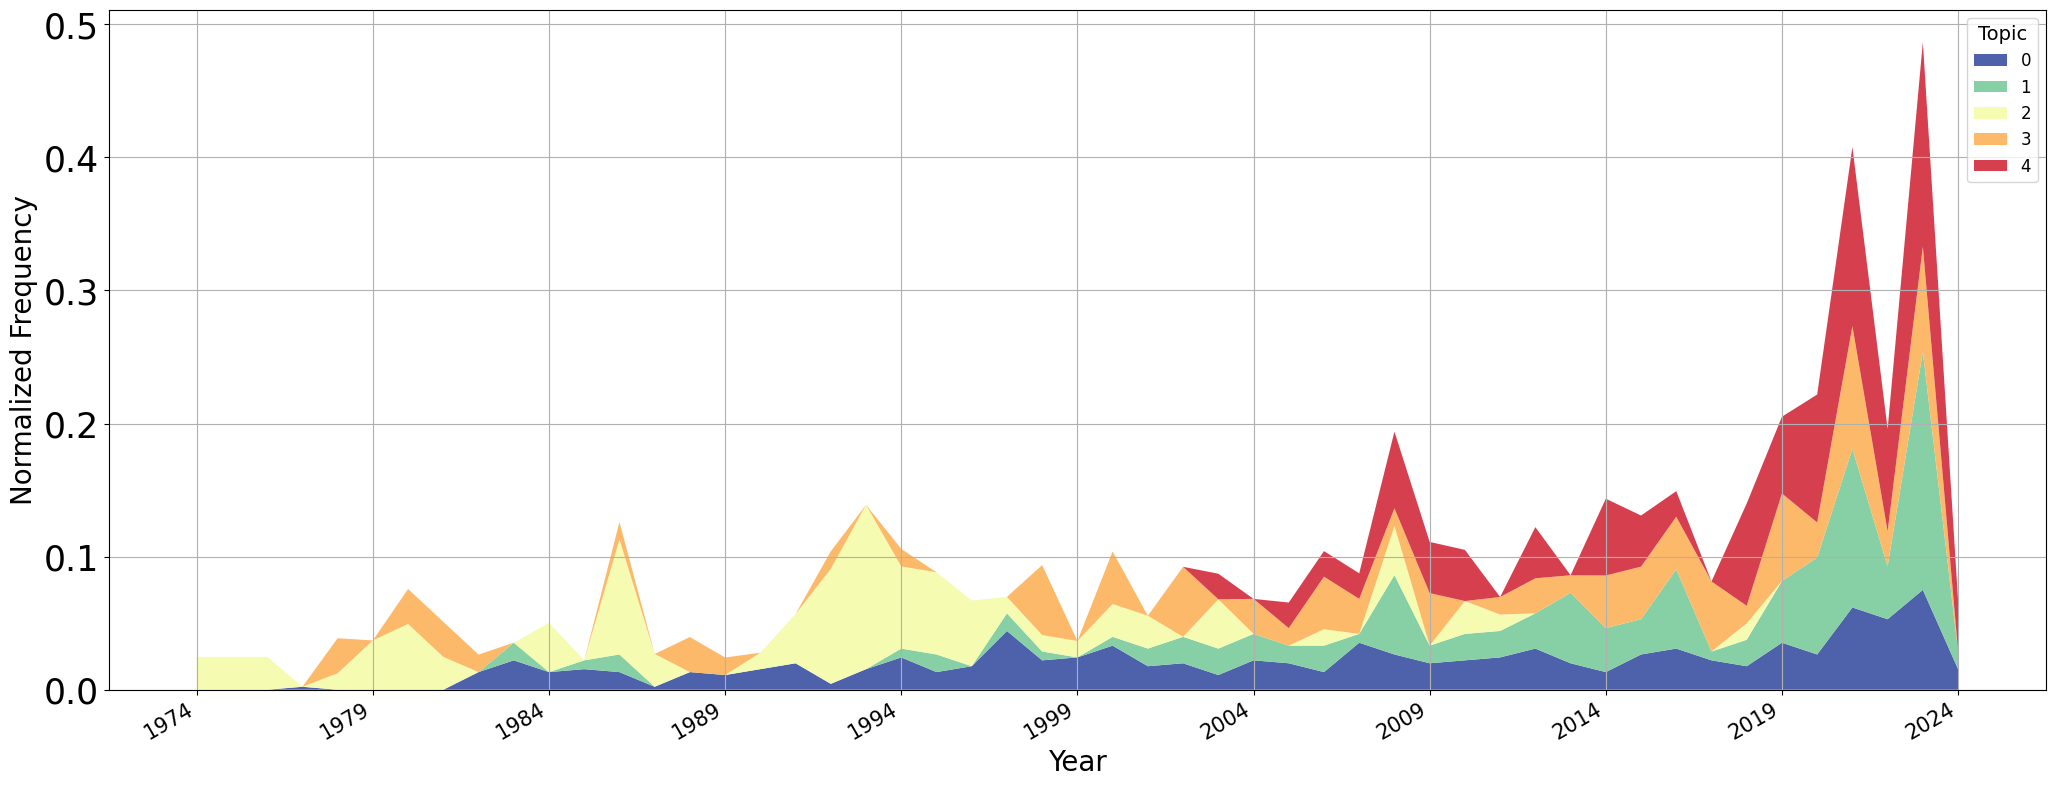

In [420]:
__plot_area_groups(g1, True)

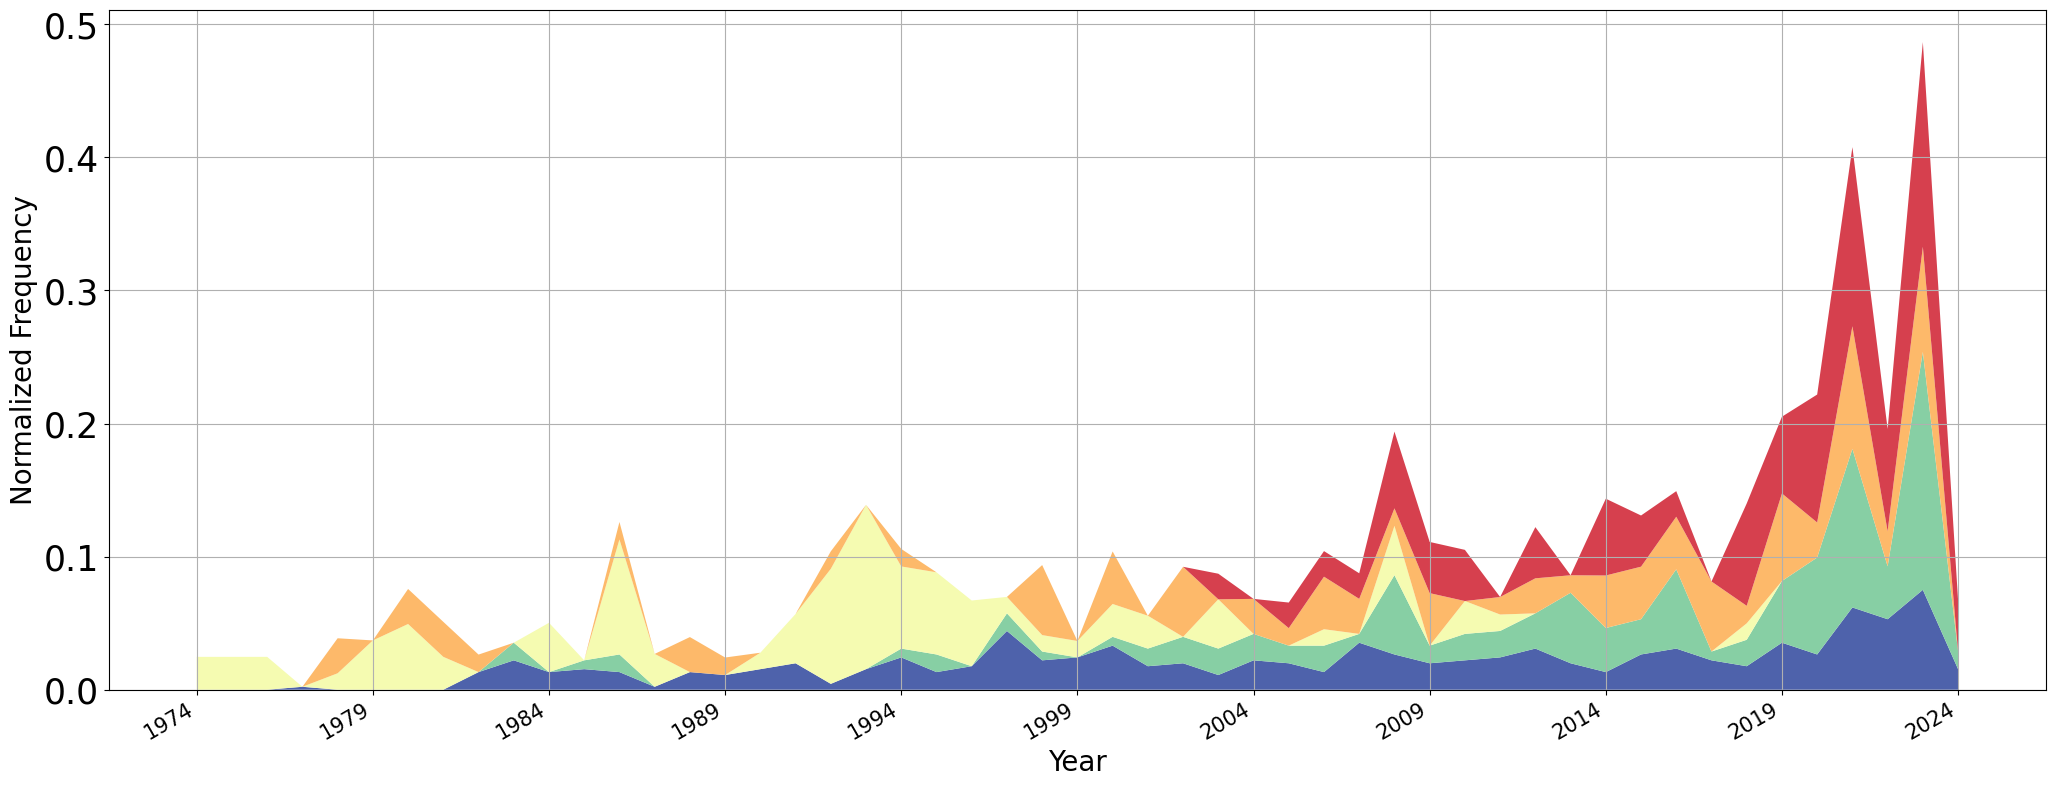

In [421]:
__plot_area_groups(g1, False)

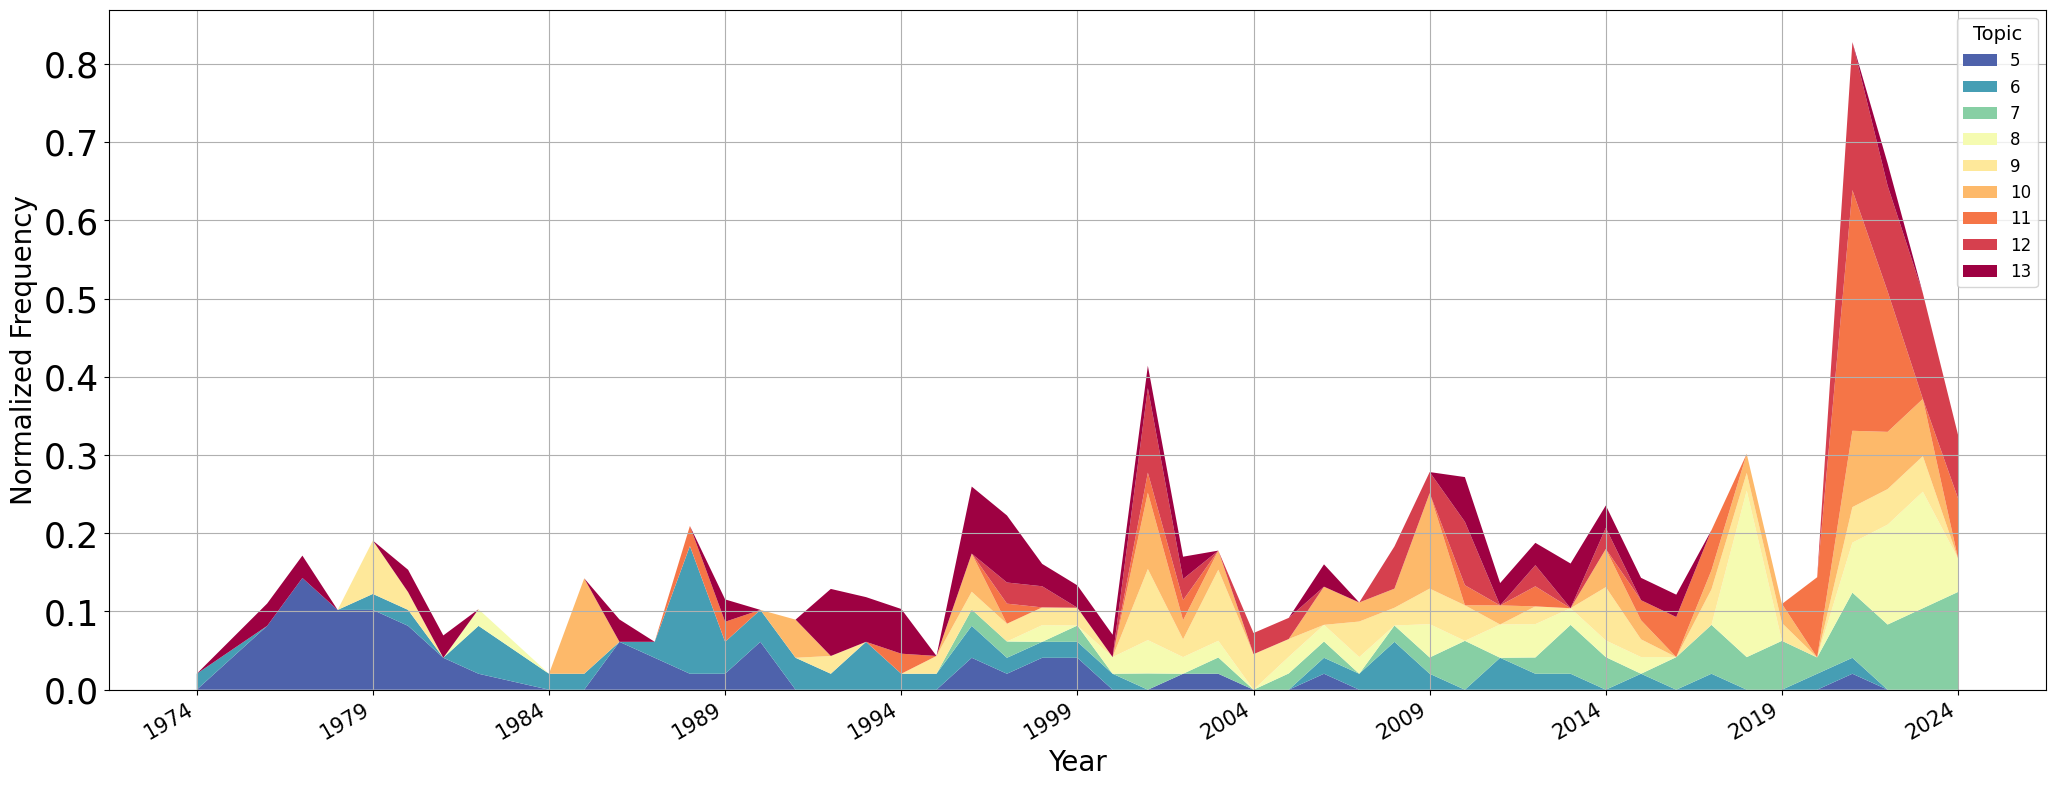

In [423]:
__plot_area_groups(g2, True)

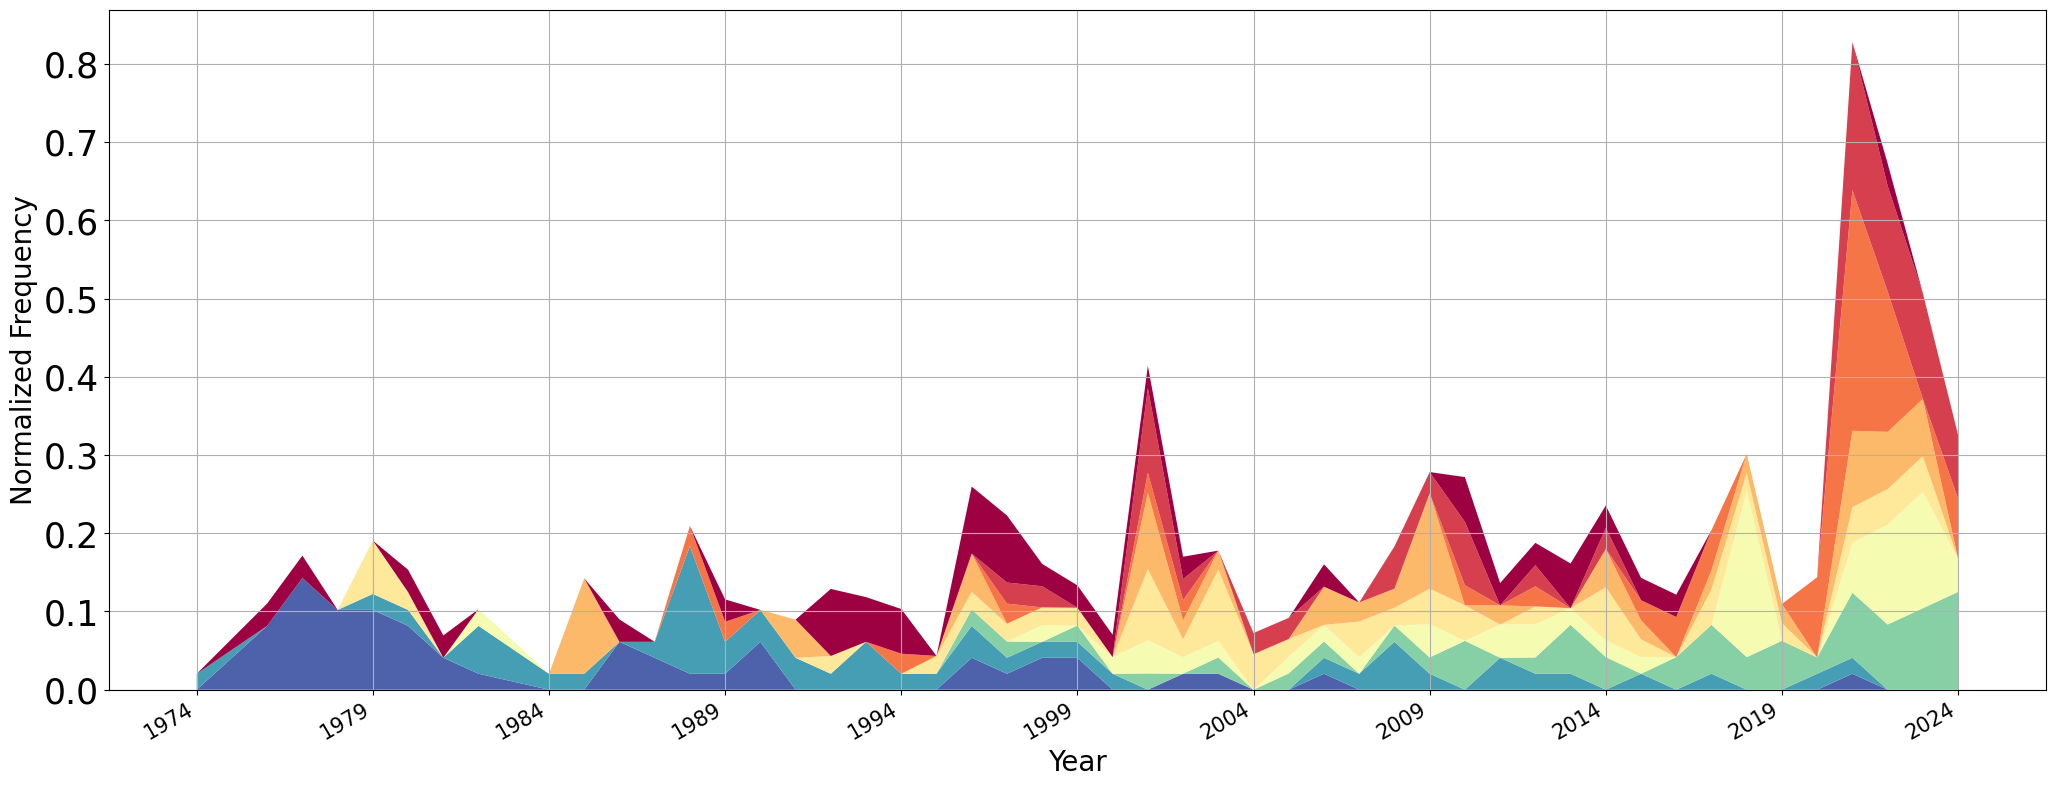

In [424]:
__plot_area_groups(g2, 0)

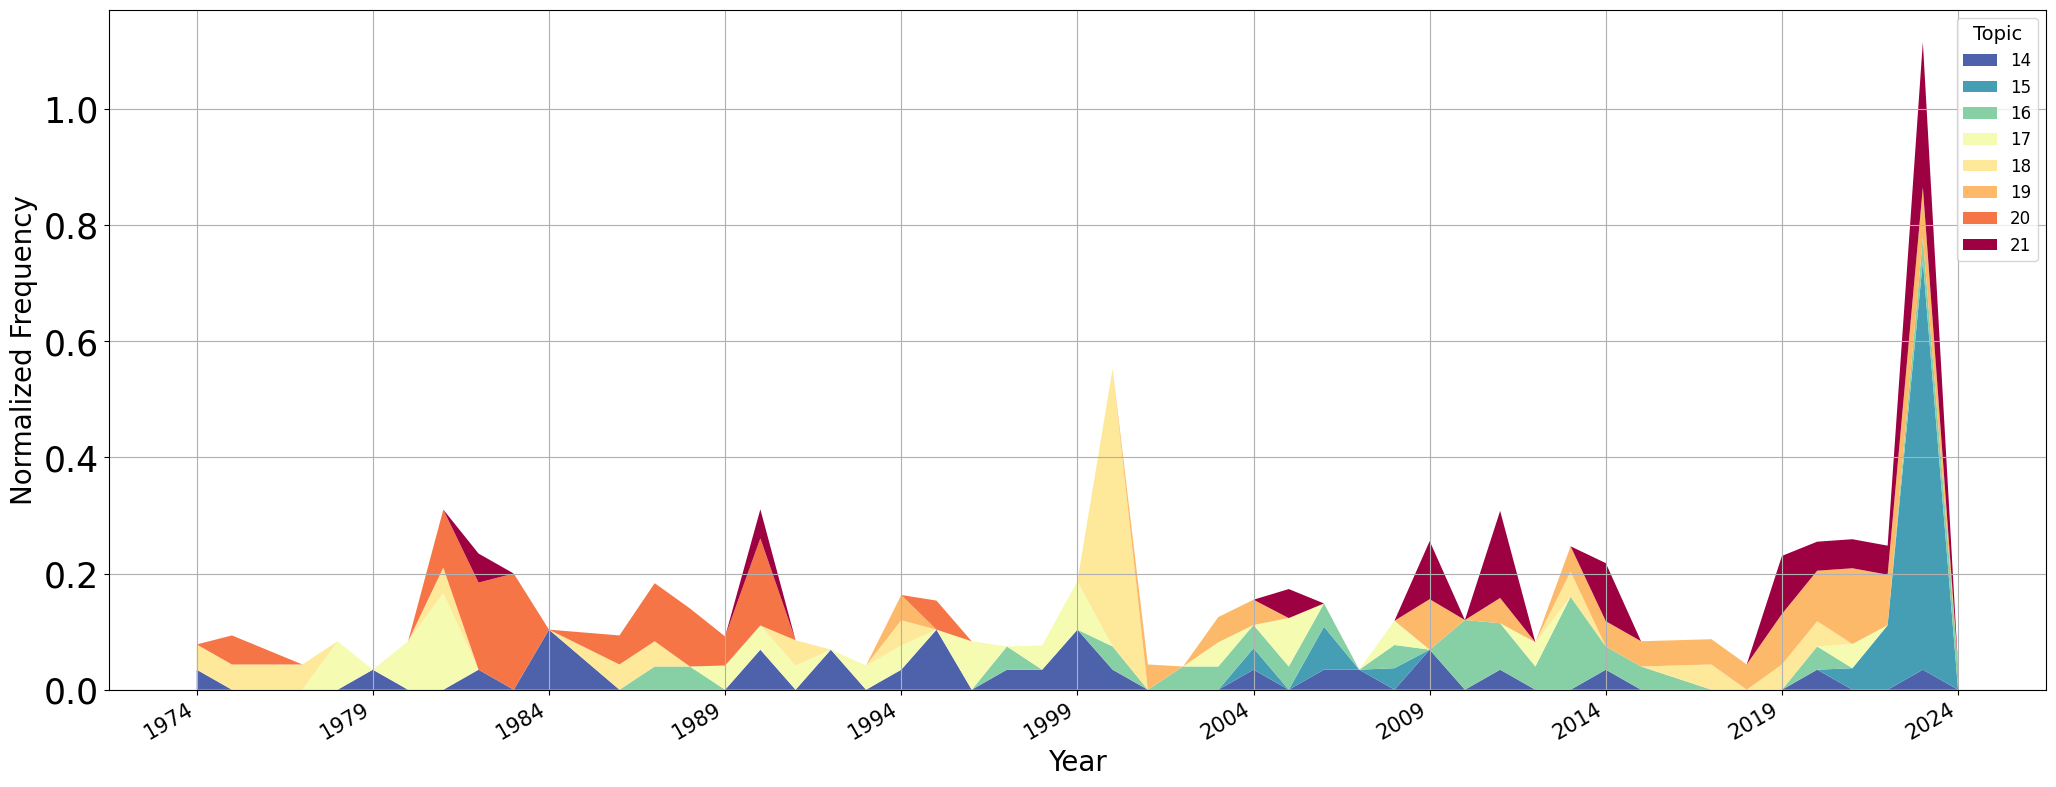

In [425]:
__plot_area_groups(g3, True)

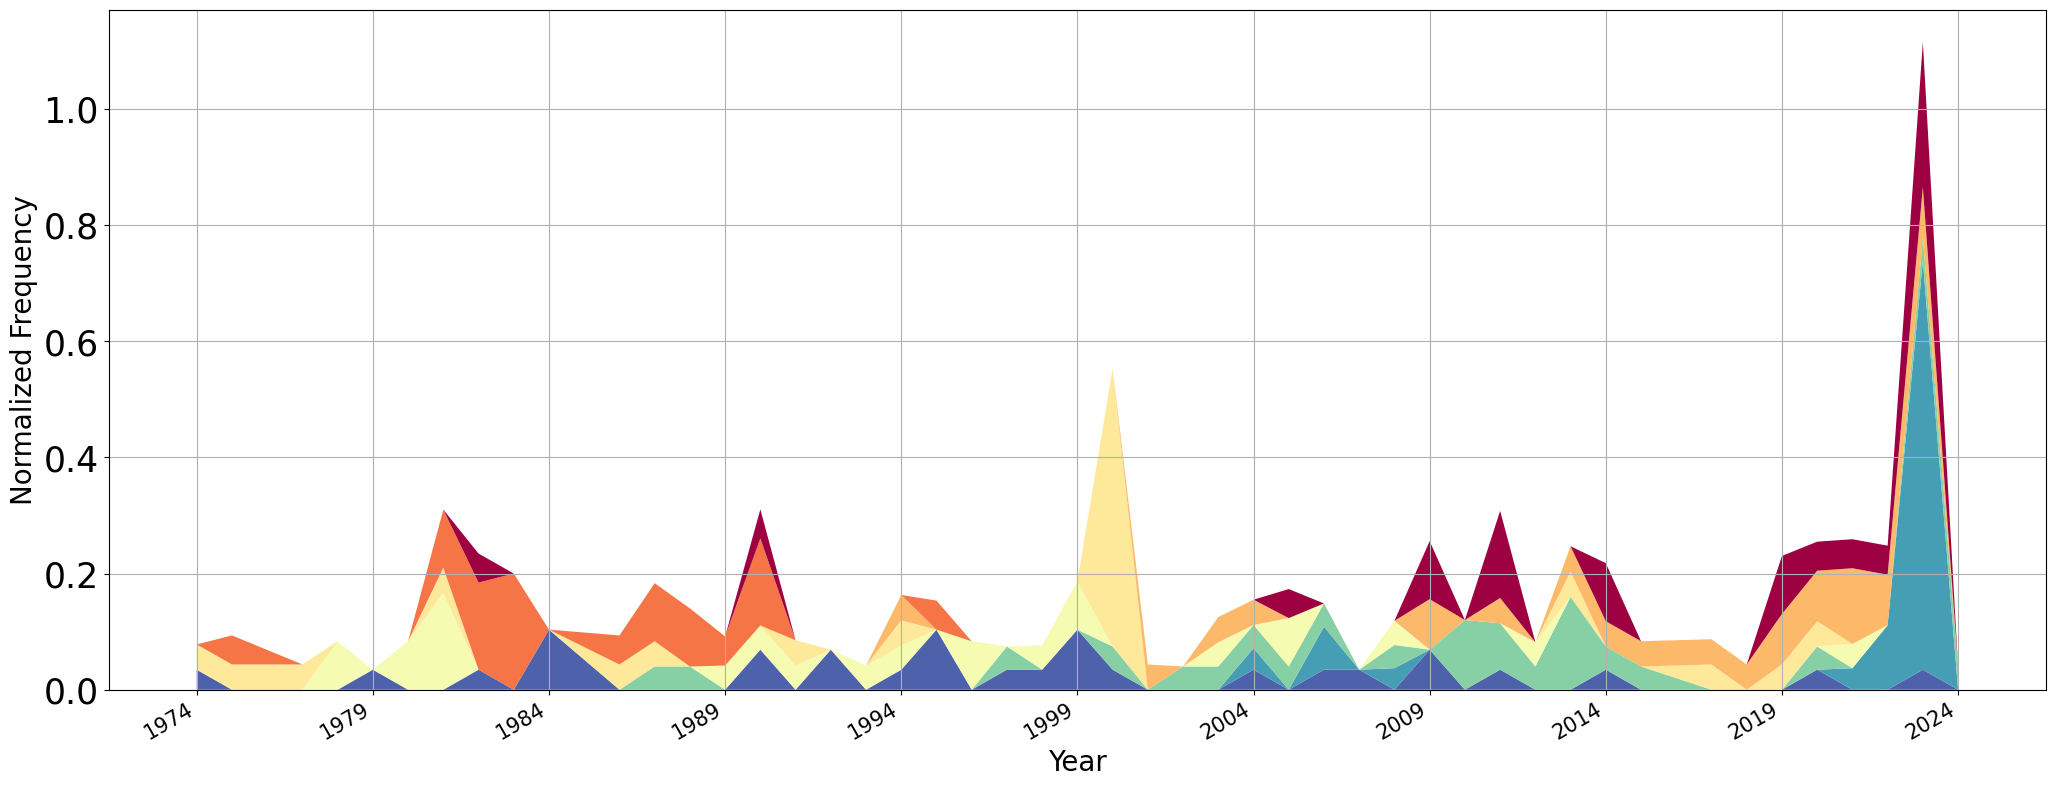

In [431]:
__plot_area_groups(g3, 0)

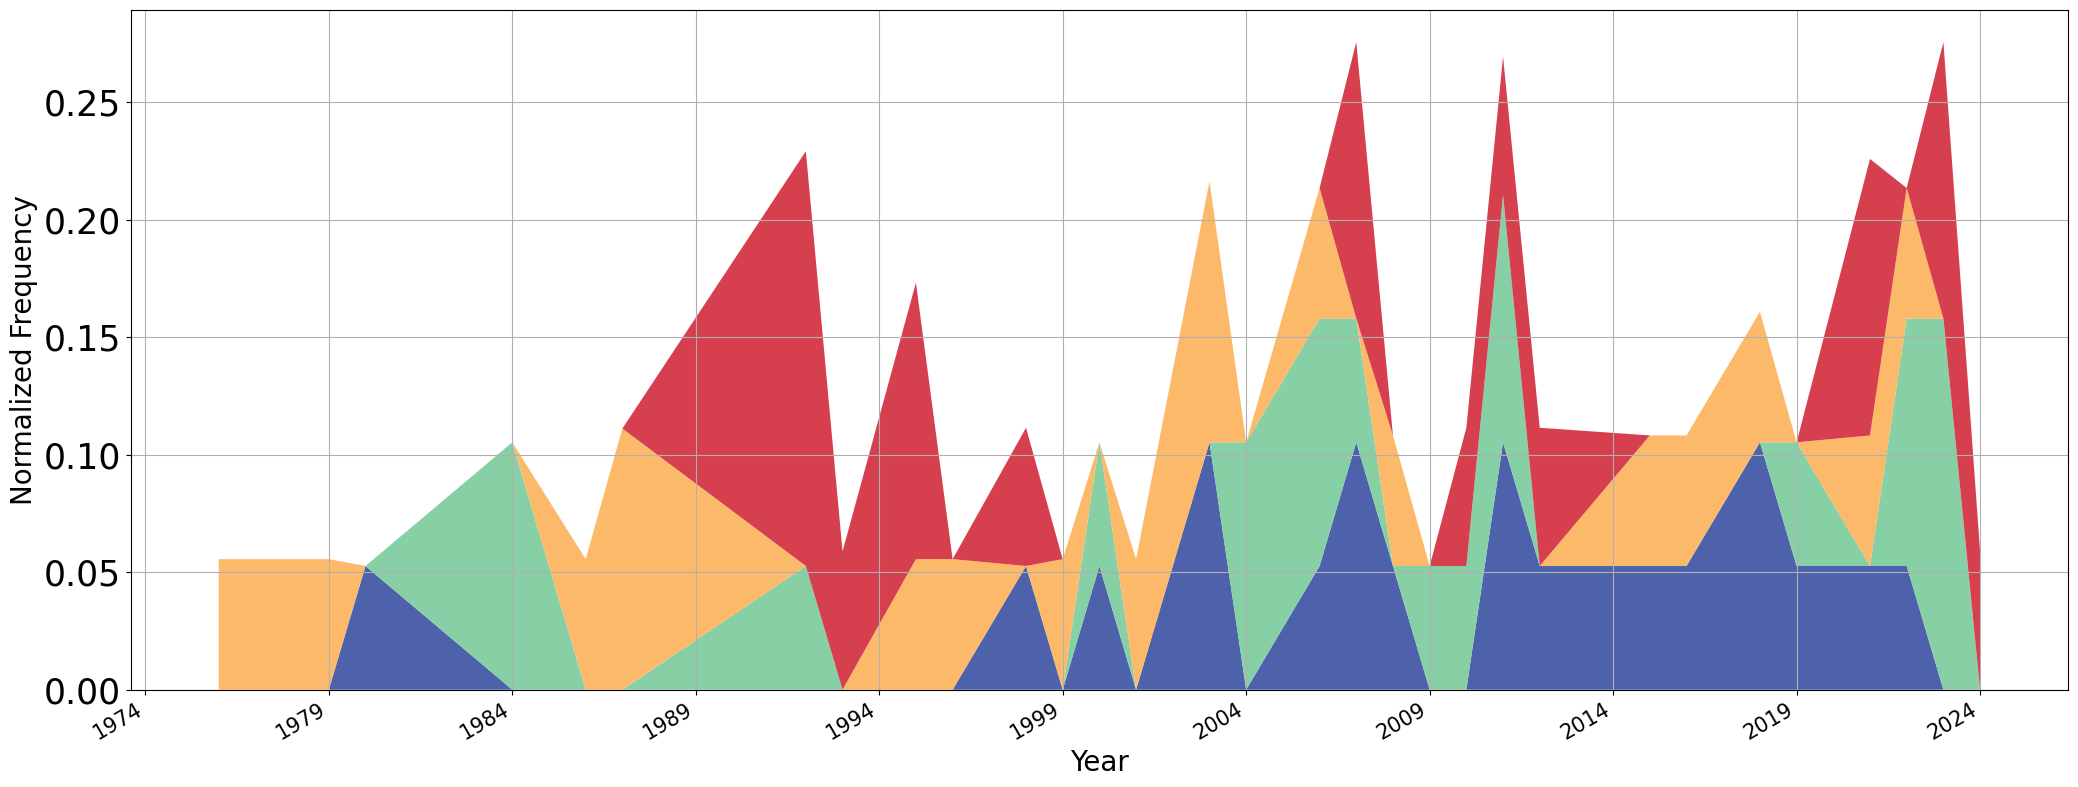

In [426]:
__plot_area_groups(g4,0 )

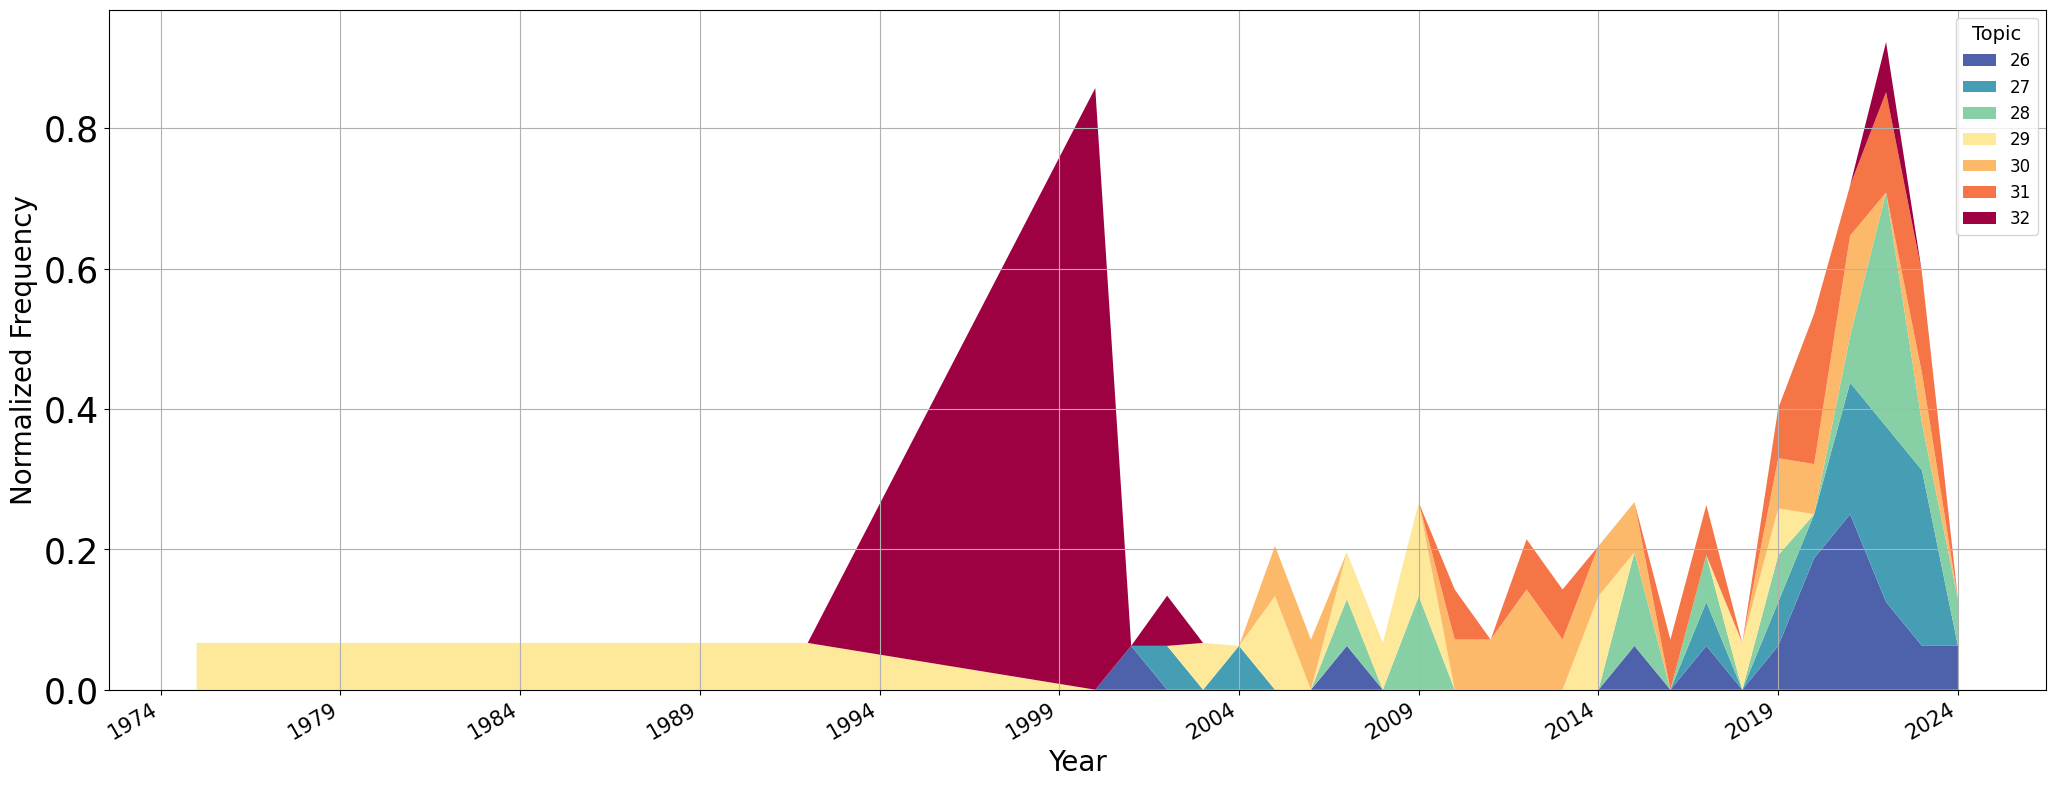

In [427]:
__plot_area_groups(g5, True)

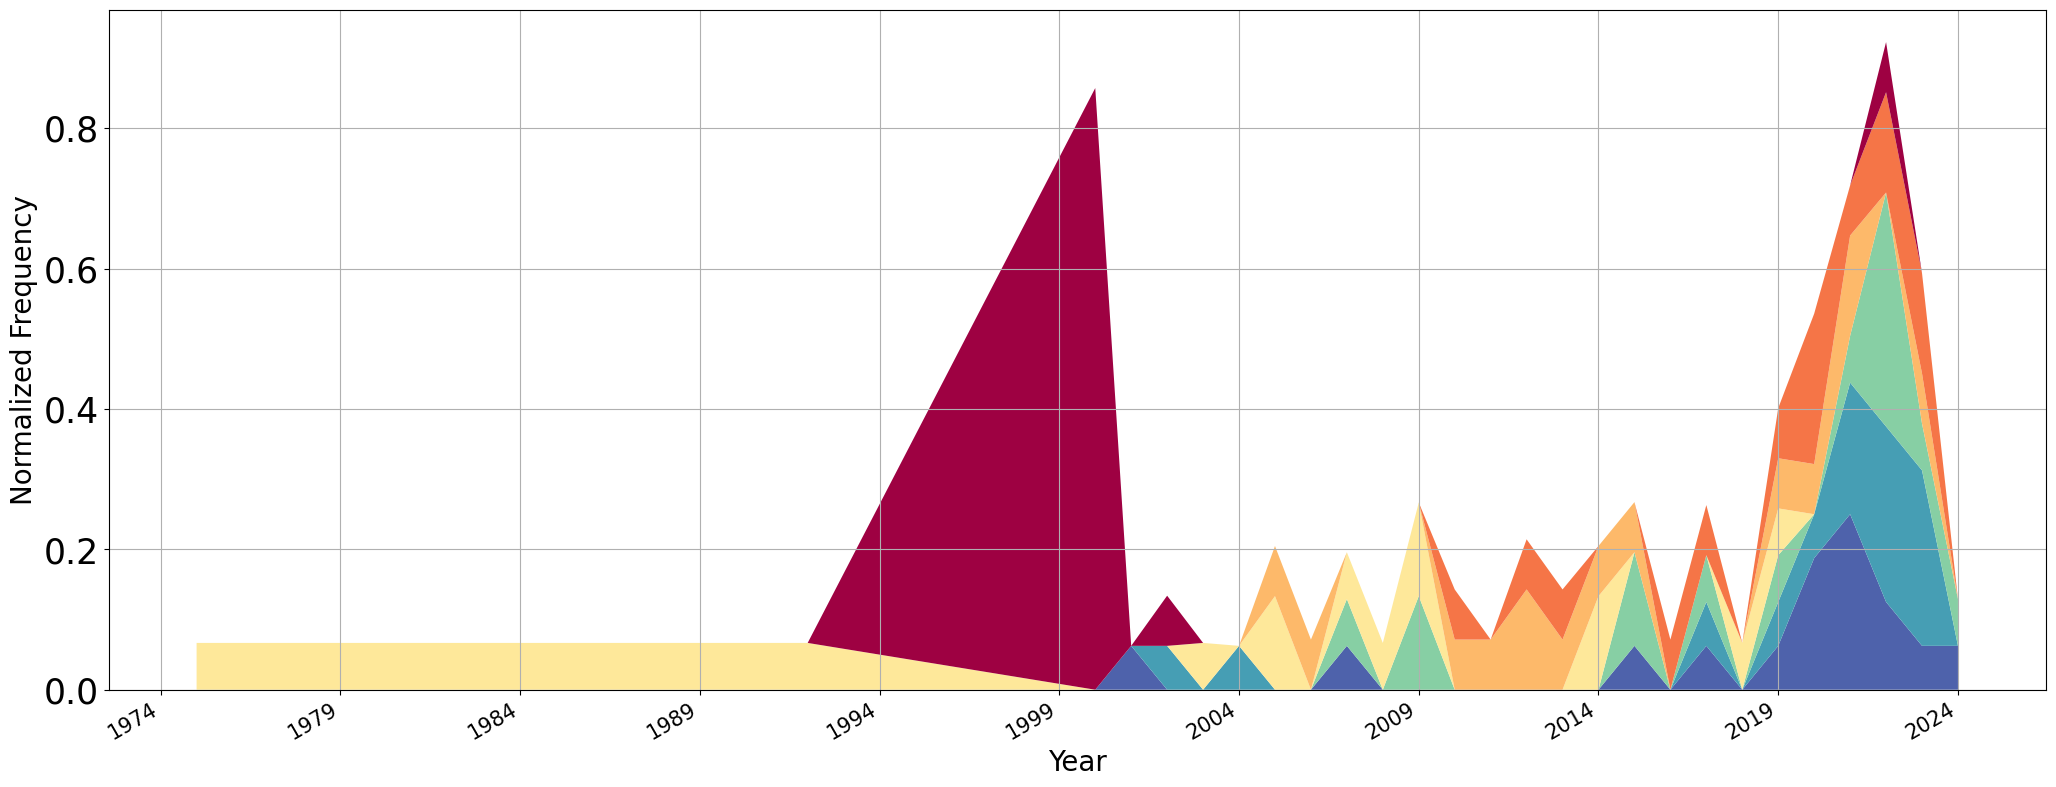

In [428]:
__plot_area_groups(g5, 0)

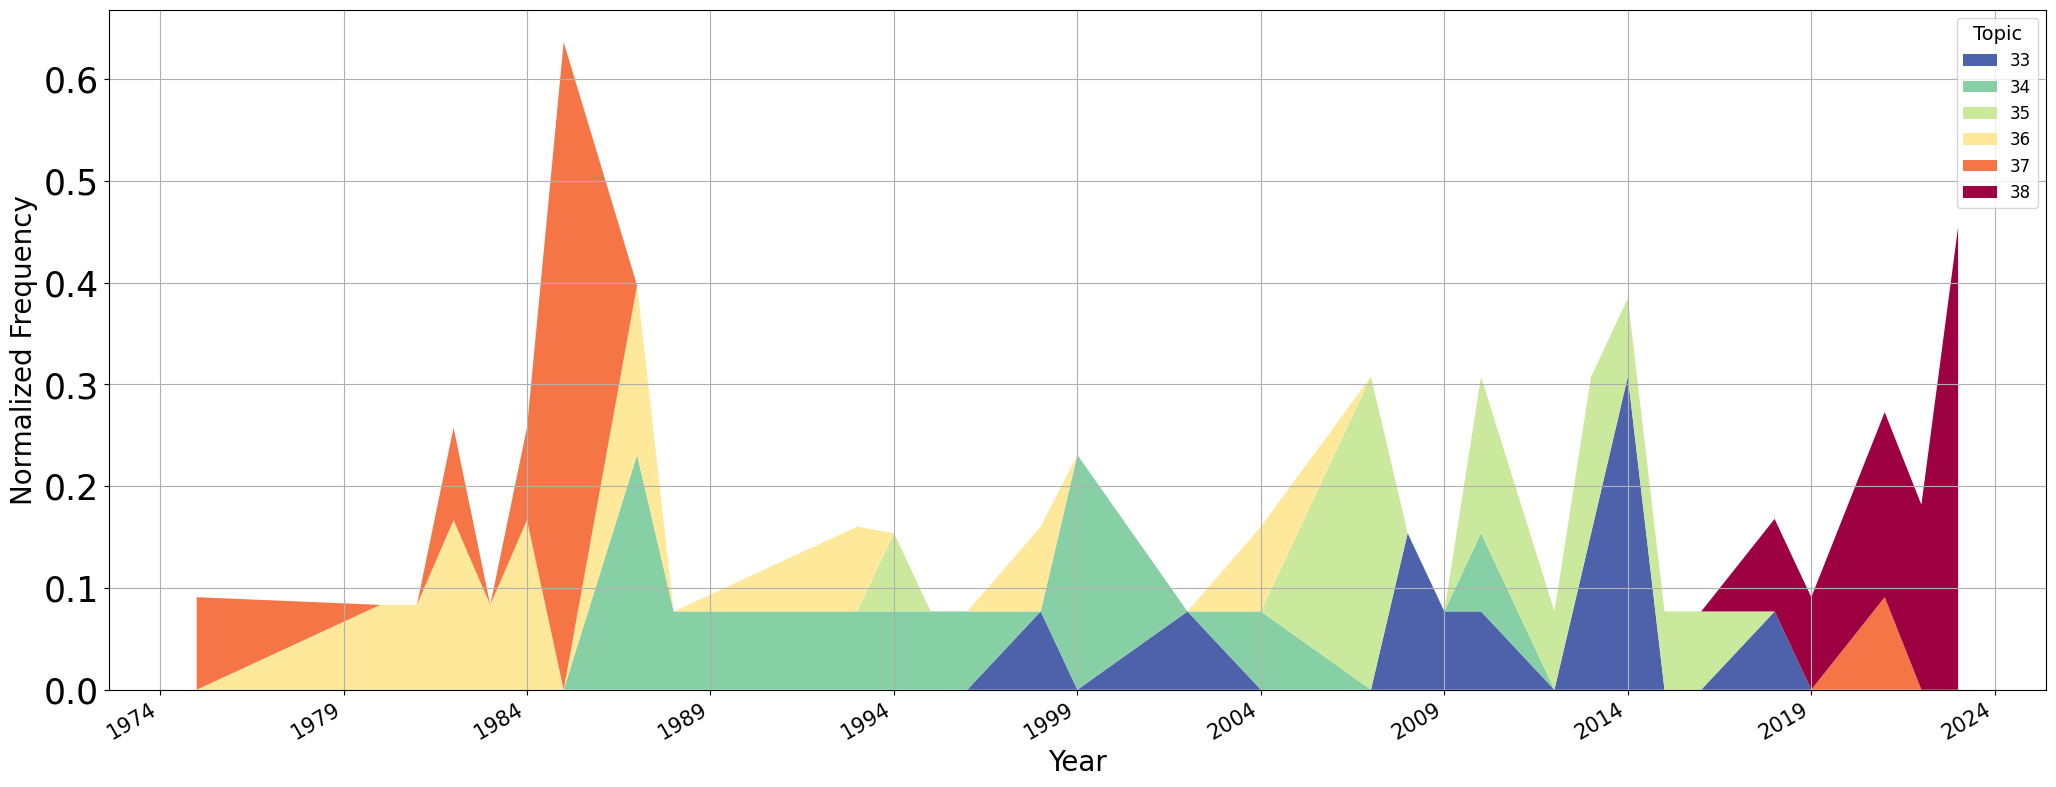

In [429]:
__plot_area_groups(g6, True)

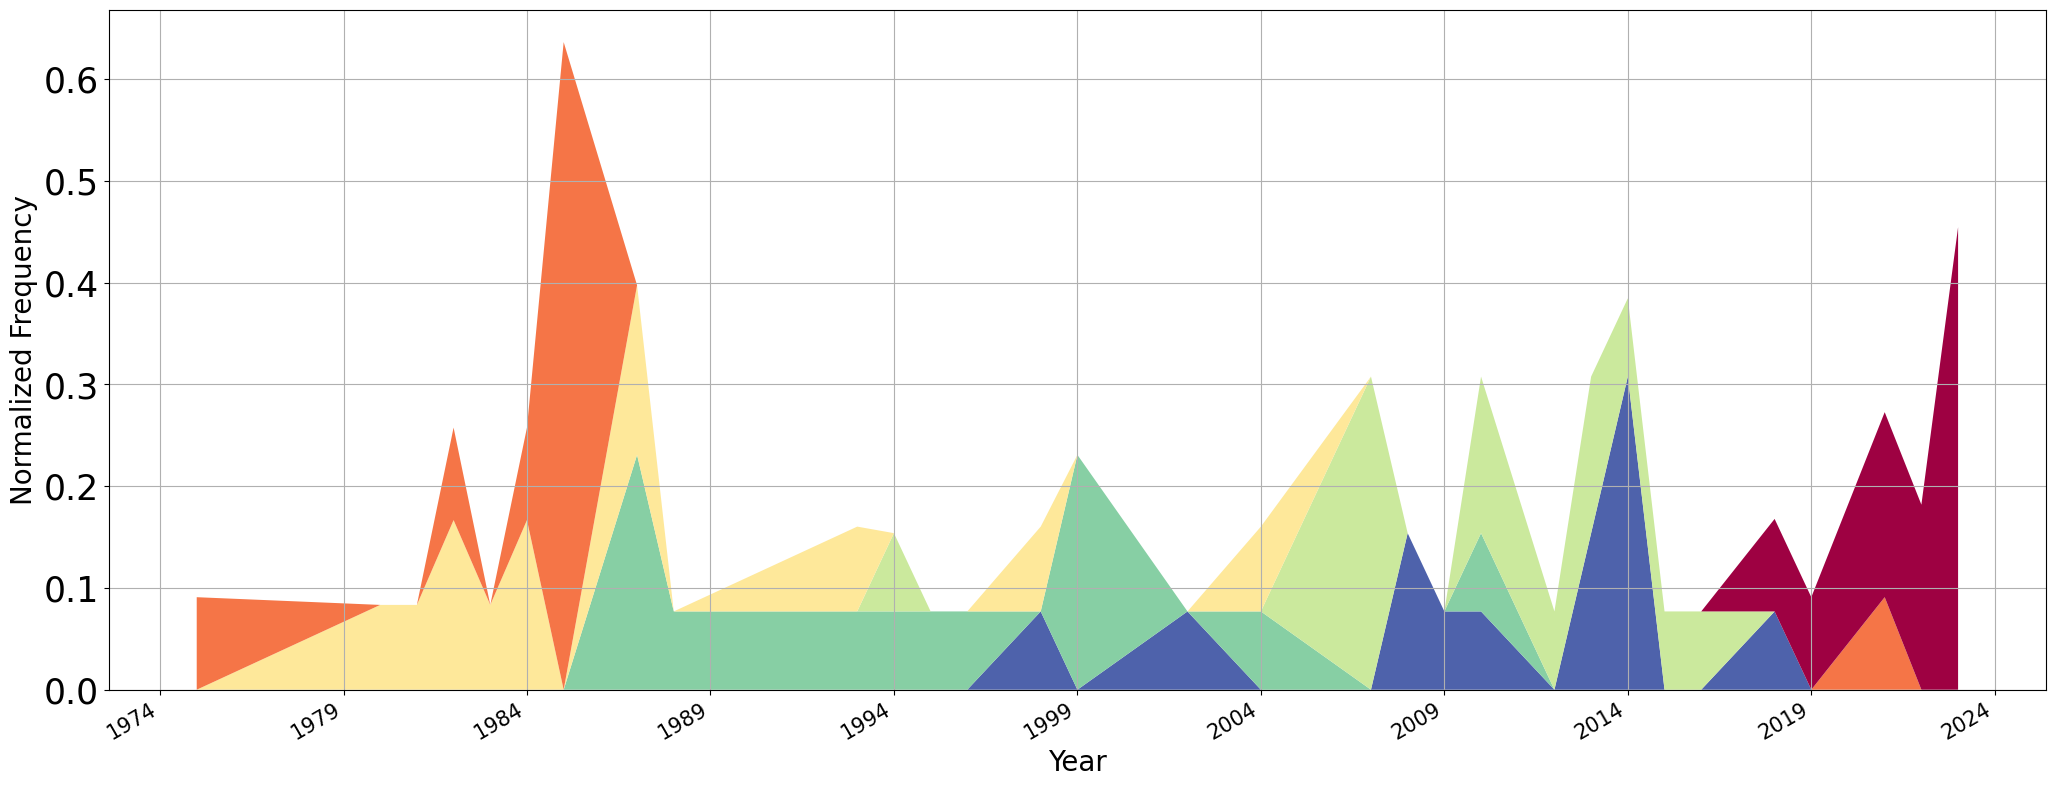

In [430]:
__plot_area_groups(g6, 0)